# Sanity check (visual): MeZO on a toy problem

Pytest already validates the three load-bearing invariants (Test A — perturbation reversibility, Test B — convergence on a tiny linear regression, Test C — SPSA estimate aligns with the true gradient on average). This notebook is a visual companion: same checks, but with **loss curves** you can show in the defense slides.

Run from the repo root:
```bash
uv run jupyter lab
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.mezo import MeZOOptimizer

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (8, 5)

## Toy task: linear regression with a single Linear layer

`y = X · W_true + small_noise`. Model: `nn.Linear(d_in, d_out, bias=False)`. MeZO must drive MSE down.

In [2]:
torch.manual_seed(0)
n, d_in, d_out = 64, 8, 4
W_true = torch.randn(d_in, d_out)
X = torch.randn(n, d_in)
Y = X @ W_true + 0.01 * torch.randn(n, d_out)

model = torch.nn.Linear(d_in, d_out, bias=False)
model.eval()
opt = MeZOOptimizer(model, lr=1e-2, eps=1e-3)

def loss_fn():
    with torch.no_grad():
        return ((model(X) - Y) ** 2).mean()

losses = []
for _ in range(3000):
    losses.append(opt.step(loss_fn))

print(f'initial loss: {losses[0]:.4f}')
print(f'final loss:   {losses[-1]:.4f}')
print(f'reduction:    {losses[0] / losses[-1]:.1f}x')

initial loss: 7.3076
final loss:   0.0001
reduction:    72654.7x


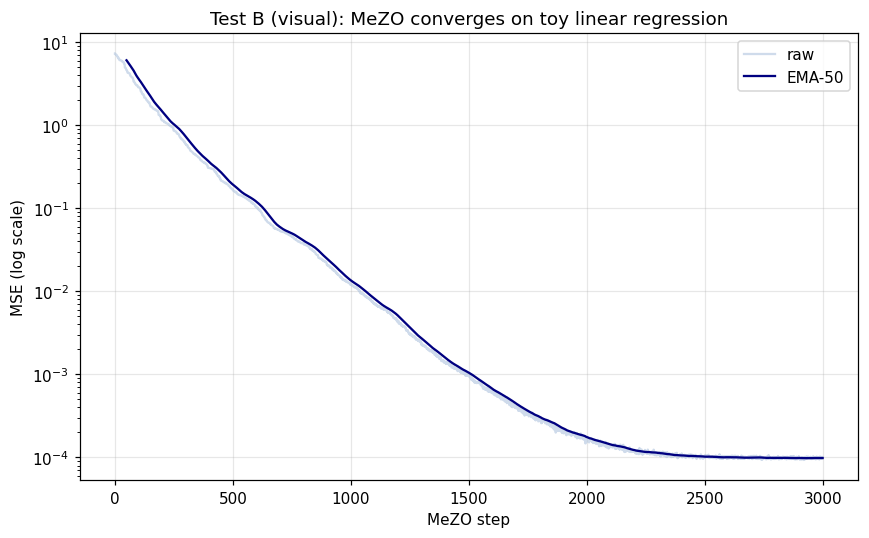

In [3]:
# Smoothed loss curve (raw MeZO loss is noisy because we report L(theta + eps*z))
losses_arr = np.array(losses)
window = 50
smoothed = np.convolve(losses_arr, np.ones(window) / window, mode='valid')

fig, ax = plt.subplots()
ax.plot(losses_arr, color='lightsteelblue', alpha=0.6, label='raw')
ax.plot(np.arange(window - 1, len(losses_arr)), smoothed, color='navy', label=f'EMA-{window}')
ax.set_yscale('log')
ax.set_xlabel('MeZO step')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Test B (visual): MeZO converges on toy linear regression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Test C (visual): SPSA estimate vs. true gradient

For many random seeds, plot `<projected_grad · z, ∇L>`. The histogram should be centered on a **positive** value — that's what makes MeZO descend on average.

mean <SPSA, true grad> = 7.3093e-01
fraction positive       = 99.80%


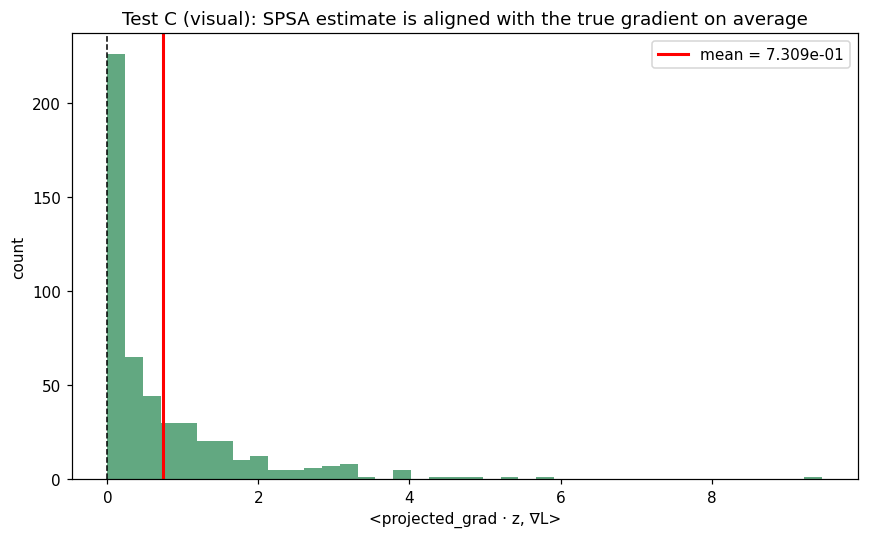

In [4]:
torch.manual_seed(1)
d_in, d_out, n = 8, 4, 32
model = torch.nn.Linear(d_in, d_out, bias=False)
model.eval()
X = torch.randn(n, d_in)
Y = torch.randn(n, d_out)

# True gradient at current theta
for p in model.parameters():
    if p.grad is not None:
        p.grad.zero_()
((model(X) - Y) ** 2).mean().backward()
true_grads = [p.grad.detach().clone() for p in model.parameters()]

opt = MeZOOptimizer(model, lr=0.0, eps=1e-4)

dots = []
with torch.no_grad():
    for k in range(500):
        seed = 2000 + k
        opt._perturb(scaling=opt.eps, seed=seed)
        lp = ((model(X) - Y) ** 2).mean().item()
        opt._perturb(scaling=-2 * opt.eps, seed=seed)
        lm = ((model(X) - Y) ** 2).mean().item()
        opt._perturb(scaling=opt.eps, seed=seed)
        g_hat = (lp - lm) / (2 * opt.eps)
        torch.manual_seed(seed)
        d = 0.0
        for p, tg in zip(model.parameters(), true_grads):
            z = torch.normal(0.0, 1.0, p.shape, device=p.device, dtype=p.dtype)
            d += float((g_hat * z * tg).sum().item())
        dots.append(d)

dots = np.array(dots)
print(f'mean <SPSA, true grad> = {dots.mean():.4e}')
print(f'fraction positive       = {(dots > 0).mean():.2%}')

fig, ax = plt.subplots()
ax.hist(dots, bins=40, color='seagreen', alpha=0.75)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.axvline(dots.mean(), color='red', linewidth=2, label=f'mean = {dots.mean():.3e}')
ax.set_xlabel('<projected_grad · z, ∇L>')
ax.set_ylabel('count')
ax.set_title('Test C (visual): SPSA estimate is aligned with the true gradient on average')
ax.legend()
plt.tight_layout()

**Interpretation.** Individual SPSA estimates are wildly noisy (the histogram spans both signs), but the mean is clearly positive. Federated MeZO's central thesis is that **N agents independently averaging their SPSA estimates** narrows this histogram by a factor ~√N — that's the variance reduction we'll measure starting from Day 2.